In [22]:
import random, simpy, math, statistics
import numpy as np
from collections import defaultdict, deque
import pandas as pd
from scipy.stats import sem
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
def pooled_fault_sim(lambda_rate=0.8, mu=1.0, team_size=4,
                     fault_rate=1/300, fault_dur=60, sim_time=3600, seed=None):
    """
    M/M/c queue where each worker (server) can go down independently.
    fault_rate: mean time between faults (per worker) = 1/λ_fault
    fault_dur:  fault duration in seconds
    """
    rng = random.Random(seed)
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=team_size)  
    stats = defaultdict(list)

    def task_generator():
        i = 0
        while True:
            yield env.timeout(rng.expovariate(lambda_rate))
            i += 1
            env.process(task(i))

    def task(i):
        arrive = env.now
        with server.request() as req:
            yield req
            wait = env.now - arrive
            service_time = rng.expovariate(mu)
            yield env.timeout(service_time)
            done = env.now
        stats["completion_time"].append(done - arrive)
        stats["wait_time"].append(wait)

    def worker_faults(worker_id):
        while True:
            # time until next fault
            yield env.timeout(rng.expovariate(fault_rate))
            server.capacity -= 1       # worker offline
            yield env.timeout(fault_dur)
            server.capacity += 1       # worker back

    # launch one fault process per worker
    for wid in range(team_size):
        env.process(worker_faults(wid))
    env.process(task_generator())
    env.run(until=sim_time)
    return {k: np.mean(v) for k, v in stats.items()}

In [24]:
def reciprocal_fault_sim(k=3, lambda_rate=0.5, mu=1.0,
                         fault_rate=1/300, fault_dur=60, sim_time=3600, seed=None):
    rng = random.Random(seed)
    env = simpy.Environment()
    
    # each stage is its own Resource(capacity=1)
    stages = [simpy.Resource(env, capacity=1) for _ in range(k)]
    stats = defaultdict(list)

    def task_generator():
        i = 0
        while True:
            yield env.timeout(rng.expovariate(lambda_rate))
            i += 1
            env.process(task(i))

    def task(i):
        t0 = env.now
        for s in stages:               # sequential processing
            with s.request() as req:
                yield req
                service_time = rng.expovariate(mu)
                yield env.timeout(service_time)
        stats["completion_time"].append(env.now - t0)

    def stage_faults(stage_id):
        while True:
            yield env.timeout(rng.expovariate(fault_rate))
            stages[stage_id].capacity = 0   # completely blocked
            yield env.timeout(fault_dur)
            stages[stage_id].capacity = 1

    for sid in range(k):
        env.process(stage_faults(sid))
    env.process(task_generator())
    env.run(until=sim_time)
    return {k: np.mean(v) for k, v in stats.items()}

,Structure,Team Size,% Jobs Completed,Mean Job Completion Time (s)
0,Pooled,3,92.357143,152.362531
1,Reciprocal,3,79.714286,159.824095
2,Pooled,4,99.392857,129.207162
3,Reciprocal,4,83.857143,156.026311
4,Pooled,5,99.892857,106.525659
5,Reciprocal,5,90.892857,141.742412
6,Pooled,6,100.000000,91.646429
7,Reciprocal,6,100.000000,103.822143


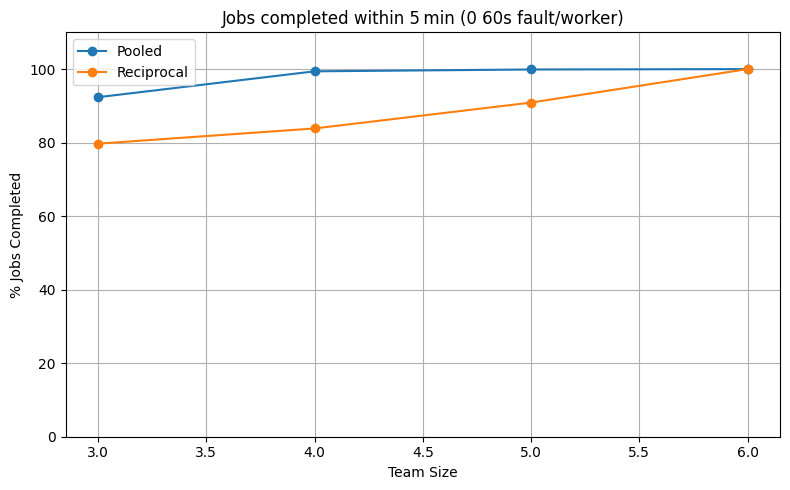

In [25]:
TEAM_SIZES = [3, 4, 5, 6]
FAULTS_PER_WORKER = 0
N_JOBS = 14
STAGES = 3
HORIZON = 300
SERVICE_MEAN = 20.0
FAULT_DUR = 60
REPS = 200

def simulate_reciprocal(team_size, seed):
    rng = random.Random(seed)
    worker_stage = [i % STAGES for i in range(team_size)]
    stage_queues = [[] for _ in range(STAGES)]
    for job in range(N_JOBS):
        for stage in range(STAGES):
            stage_queues[stage].append((job, stage))
    token_done = {}
    job_done = [None] * N_JOBS
    workers = []
    jobs_spawned = set() # which job IDs are already in the queue
    
    for _ in range(team_size):
        intervals = []
        for _ in range(FAULTS_PER_WORKER):
            start = rng.uniform(0, HORIZON - FAULT_DUR)
            intervals.append((start, start + FAULT_DUR))
        workers.append({"remain": 0, "token": None, "faults": intervals})
        
    for t in range(HORIZON):
        for wid, w in enumerate(workers):
            st = worker_stage[wid]
            if w["remain"] > 0:
                w["remain"] -= 1
                if w["remain"] == 0:
                    job_id, stage_id = w["token"]
                    token_done[(job_id, stage_id)] = t
                    if sum(1 for s in range(STAGES) if (job_id, s) in token_done) == STAGES:
                        job_done[job_id] = t
                    w["token"] = None
            in_fault = any(a <= t < b for a, b in w["faults"])
            if w["remain"] == 0 and not in_fault and stage_queues[st]:
                tok = stage_queues[st].pop(0)
                w["token"] = tok
                w["remain"] = max(1, math.ceil(rng.expovariate(1 / SERVICE_MEAN)))
    finished = [ct for ct in job_done if ct is not None]
    pct_complete = 100 * len(finished) / N_JOBS
    mean_time = np.mean(finished) if finished else np.nan
    return pct_complete, mean_time

def simulate_pooled(team_size, seed):
    rng = random.Random(seed)
    waiting = [(j,s) for j in range(N_JOBS) for s in range(STAGES)]
    token_done = {}
    job_done = [None]*N_JOBS
    workers=[]
    for _ in range(team_size):
        intervals=[]
        for _ in range(FAULTS_PER_WORKER):
            start=rng.uniform(0,HORIZON-FAULT_DUR)
            intervals.append((start,start+FAULT_DUR))
        workers.append({"remain":0,"token":None,"faults":intervals})
    for t in range(HORIZON):
        for w in workers:
            if w["remain"]>0:
                w["remain"]-=1
                if w["remain"]==0:
                    job_id,stage_id=w["token"]
                    token_done[(job_id,stage_id)]=t
                    if sum(1 for s in range(STAGES) if (job_id,s) in token_done)==STAGES:
                        job_done[job_id]=t
                    w["token"]=None
            in_fault=any(a<=t<b for a,b in w["faults"])
            if w["remain"]==0 and not in_fault and waiting:
                tok=waiting.pop(0)
                w["token"]=tok
                w["remain"]=max(1, math.ceil(rng.expovariate(1/SERVICE_MEAN)))
    finished=[ct for ct in job_done if ct is not None]
    pct_complete=100*len(finished)/N_JOBS
    mean_time=np.mean(finished) if finished else np.nan
    return pct_complete, mean_time

records=[]
for size in TEAM_SIZES:
    for struct, sim in [("Pooled", simulate_pooled), ("Reciprocal", simulate_reciprocal)]:
        pct_runs=[]
        time_runs=[]
        for rep in range(REPS):
            pct, mtime = sim(size, 10000*size + rep)
            pct_runs.append(pct)
            time_runs.append(mtime)
        records.append({
            "Structure": struct,
            "Team Size": size,
            "% Jobs Completed": np.mean(pct_runs),
            "Mean Job Completion Time (s)": np.nanmean(time_runs)
        })
df=pd.DataFrame(records)
display(df)

# Percentage jobs completed
plt.figure(figsize=(8, 5))
for struct in df["Structure"].unique():
    subset=df[df["Structure"]==struct]
    plt.plot(subset["Team Size"], subset["% Jobs Completed"], marker="o", label=struct)
plt.xlabel("Team Size")
plt.ylabel("% Jobs Completed")
plt.title("Jobs completed within 5 min (0 60s fault/worker)")
plt.ylim(0,110)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

,Structure,Team Size,% Jobs Completed,Mean Job Completion Time (s)
0,Pooled,3,49.571429,159.903633
1,Reciprocal,3,40.392857,169.723871
2,Pooled,4,65.571429,155.710347
3,Reciprocal,4,44.821429,157.994698
4,Pooled,5,82.464286,155.711939
5,Reciprocal,5,54.464286,155.485990
6,Pooled,6,93.250000,148.594819
7,Reciprocal,6,86.607143,158.141829


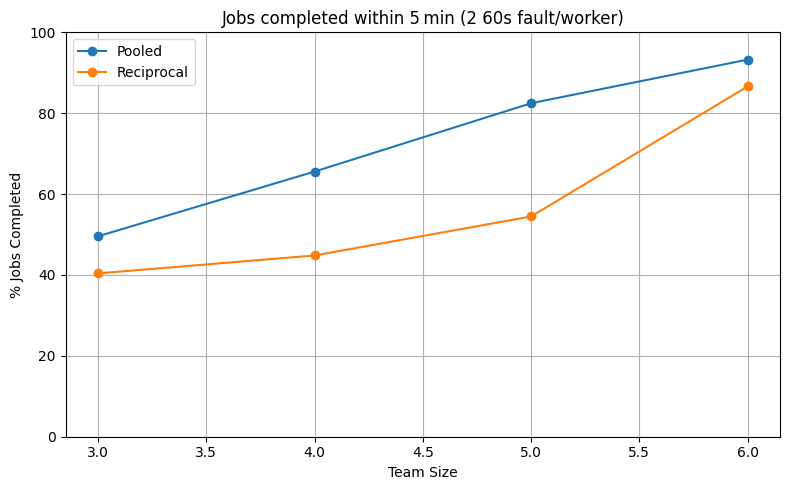

In [26]:
TEAM_SIZES = [3, 4, 5, 6]
FAULTS_PER_WORKER = 2
N_JOBS = 14
STAGES = 3
HORIZON = 300
SERVICE_MEAN = 30.0
FAULT_DUR = 60
REPS = 200

records=[]
for size in TEAM_SIZES:
    for struct, sim in [("Pooled", simulate_pooled), ("Reciprocal", simulate_reciprocal)]:
        pct_runs=[]
        time_runs=[]
        for rep in range(REPS):
            pct, mtime = sim(size, 10000*size + rep)
            pct_runs.append(pct)
            time_runs.append(mtime)
        records.append({
            "Structure": struct,
            "Team Size": size,
            "% Jobs Completed": np.mean(pct_runs),
            "Mean Job Completion Time (s)": np.nanmean(time_runs)
        })

df=pd.DataFrame(records)
display(df)

# Percentage jobs completed
plt.figure(figsize=(8, 5))
for struct in df["Structure"].unique():
    subset=df[df["Structure"]==struct]
    plt.plot(subset["Team Size"], subset["% Jobs Completed"], marker="o", label=struct)
plt.xlabel("Team Size")
plt.ylabel("% Jobs Completed")
plt.title("Jobs completed within 5 min (2 60s fault/worker)")
plt.ylim(0,100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
def plot_team_size_by_tasks_completed(full_team_summary, title):
    agg = (
        full_team_summary
        .groupby(["fault", "condition", "team_size"])["num_tasks_completed"]
        .agg(["mean", sem])
        .reset_index()
        .rename(columns={"mean": "avg_completed", "sem": "sem_completed"})
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    fig.suptitle(title, fontsize=14, weight="bold", y=1.02)
    
    palette = {"pooled": "#1f77b4", "reciprocal": "#ff7f0e"}
    
    for ax, fault_state in zip(axes, [0, 1]):
        sub_fault = agg[agg["fault"] == fault_state]
        for network, color in palette.items():
            sub = sub_fault[sub_fault["condition"] == network].sort_values("team_size")
            x = sub["team_size"].values
            y = sub["avg_completed"].values
            e = sub["sem_completed"].values
            
            ax.plot(x, y,
                    marker="o",
                    markersize=6,
                    linewidth=2,
                    label=network.capitalize(),
                    color=color)
            # shaded CI
            ax.fill_between(x, y - e, y + e,
                            alpha=0.2,
                            color=color,
                            linewidth=0)
        
        ax.set_title("Faults" if fault_state == 1 else "No Faults",
                     fontsize=12, weight="semibold")
        ax.set_xlabel("Team size (members)")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    axes[0].set_ylabel("Tasks completed")
    axes[0].set_ylim(0, full_team_summary["num_tasks_completed"].max() * 1.1)
    
    axes[1].legend_.remove() if axes[1].legend_ else None

    handles, labels = axes[0].get_legend_handles_labels()

    # create a single legend for the whole figure
    fig.legend(
        handles=handles,
        labels=labels,
        title="Network",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()
    
    plt.tight_layout()
    # fig.savefig("Experiment1_simulations.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    agg = (
    full_team_summary
    .groupby(["fault", "condition", "team_size"])["num_tasks_completed"]
    .agg(["mean", sem])
    .reset_index()
    .rename(columns={"mean": "avg_completed", "sem": "sem_completed"})
)
    print(agg.to_string())

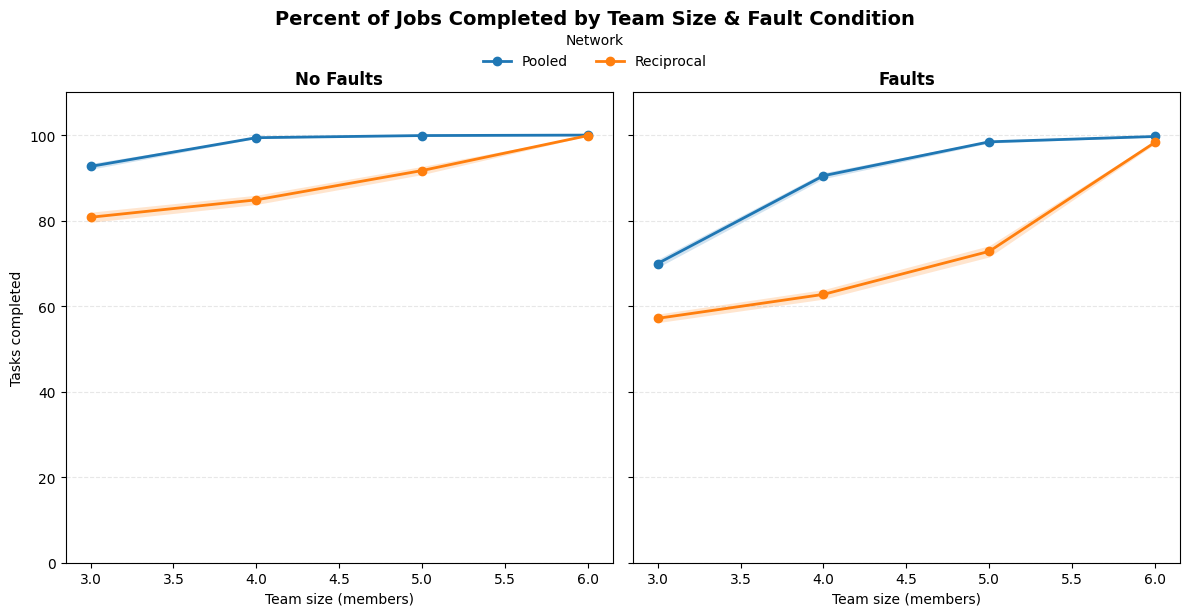

<Figure size 640x480 with 0 Axes>

    fault   condition  team_size  avg_completed  sem_completed
0       0      pooled          3      92.678571       0.678269
1       0      pooled          4      99.392857       0.158329
2       0      pooled          5      99.892857       0.061547
3       0      pooled          6     100.000000       0.000000
4       0  reciprocal          3      80.785714       1.192211
5       0  reciprocal          4      84.857143       1.084285
6       0  reciprocal          5      91.714286       0.950579
7       0  reciprocal          6      99.892857       0.079699
8       1      pooled          3      69.964286       0.942259
9       1      pooled          4      90.500000       0.698149
10      1      pooled          5      98.428571       0.282647
11      1      pooled          6      99.678571       0.104967
12      1  reciprocal          3      57.142857       0.998666
13      1  reciprocal          4      62.750000       1.116115
14      1  reciprocal          5      72.821429       1

In [28]:
TEAM_SIZES = [3, 4, 5, 6]
N_JOBS = 14
STAGES = 3
HORIZON = 300
SERVICE_MEAN = 20.0
FAULT_DUR = 60
REPS = 200

def simulate_and_record(fault_counts):
    rows = []
    for faults in fault_counts:
        global FAULTS_PER_WORKER
        FAULTS_PER_WORKER = faults
        for size in TEAM_SIZES:
            for condition, sim_fn in [("pooled", simulate_pooled),
                                      ("reciprocal", simulate_reciprocal)]:
                for rep in range(REPS):
                    pct, _ = sim_fn(size, seed=10000*faults + rep)
                    rows.append({
                        "fault": int(faults>0),
                        "condition": condition,
                        "team_size": size,
                        "num_tasks_completed": pct
                    })
    return pd.DataFrame(rows)

# 1) simulate for no‐faults (0) and faults (2 per worker)
full_team_summary = simulate_and_record([0, 2])

plot_team_size_by_tasks_completed(
    full_team_summary,
    "Percent of Jobs Completed by Team Size & Fault Condition"
)


In [29]:
STAGES = 3
HORIZON = 300
SERVICE_MEAN = 20.0
FAULT_DUR = 60

def stage_counts(team_size, STAGES=3):
    # round-robin assignment
    base, r = divmod(team_size, STAGES)
    return [base + (1 if s < r else 0) for s in range(STAGES)]

def bottleneck_capacity(team_size, SERVICE_MEAN=20.0, STAGES=3):
    counts = stage_counts(team_size, STAGES)
    mu_s = [c / SERVICE_MEAN for c in counts]     
    return min(mu_s)        

def make_bursty_rate(
    lam_mean,                
    base_frac=0.5,           
    burst_intensity=3.0,     
    burst_rate=0.02,         
    burst_duration=(20,60),  
    horizon=280):

    rng = random.Random()
    n_bursts = np.random.poisson(burst_rate * horizon)
    bursts = []
    for _ in range(n_bursts):
        start = rng.uniform(0, horizon)
        dur = rng.uniform(*burst_duration)
        bursts.append((start, start + dur))

    # Build unnormalized rate = base + bursts
    base = base_frac
    def raw_rate(t):
        in_burst = any(a <= t < b for (a,b) in bursts)
        return base + (burst_intensity - base) * (1.0 if in_burst else 0.0)

    samples = [raw_rate(t) for t in range(horizon)]
    avg = sum(samples) / max(1, len(samples))
    scale = lam_mean / avg if avg > 0 else 0.0

    def rate(t):
        return scale * raw_rate(t)
    return rate

def lam_t(t, mode, lam_mean, amp=0.0, period=60, on_frac=0.5, peak_factor=2.0, period_jitter=0.2):
    if mode == "constant":
        return lam_mean
    if mode == "fluct_sine":
        rate_fn = make_bursty_rate(lam_mean_sine, base_frac=0.01, burst_intensity=8.0, burst_rate=0.01, burst_duration=(60,100), horizon=HORIZON)
        return rate_fn(t)
    return 0.0

def extract_arrival_schedule(logs):
    arr = sorted([t for (t, _job) in logs["arrivals"]])
    return arr # Return a sorted list of arrival ticks (one entry per job)

def extract_arrival_schedule(logs):
    # returns sorted list of arrival ticks (one per job)
    return sorted(t for (t, _job) in logs["arrivals"])

def features_from_run(jobs_completed, mean_flow, throughput,
                      arrivals_before280, arrival_times, horizon, B=12):
    # normalized histogram of arrival times
    hist, _ = np.histogram(arrival_times, bins=np.linspace(0, horizon, B+1))
    hist = hist.astype(float)
    hist = hist / max(1.0, hist.sum())
    mf = 0.0 if (mean_flow is None or np.isnan(mean_flow)) else float(mean_flow)
    return np.concatenate([
        np.array([jobs_completed, mf, throughput, arrivals_before280], dtype=float),
        hist
    ])

In [30]:
def simulate_reciprocal(team_size,
                        seed,
                        workload_mode="upfront",
                        N_JOBS=14,
                        lambda_rate=14/250,
                        amp=0.8,
                        period=150,
                        faults_per_worker=0,
                        log_events=True,
                        arrival_schedule=None):
    arrivals_log, enqueue_log, start_log, finish_log = [], [], [], []

    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)
    stage_queues = [deque() for _ in range(STAGES)]

    # Fixed stage per worker
    worker_stage = [i % STAGES for i in range(team_size)]
    workers = []
    for wid in range(team_size):
        intervals = []
        for _ in range(faults_per_worker):
            start = rng.uniform(0, HORIZON - FAULT_DUR)
            intervals.append((start, start + FAULT_DUR))
        workers.append({"stage": worker_stage[wid],
                        "remain": 0,
                        "token": None,
                        "faults": intervals})

    next_job_id = 0
    arrival_time = {}
    token_done = set()
    completion_time = {}

    # Upfront enqueue at t=0 (still need the time loop to process!)
    if arrival_schedule is None and workload_mode == "upfront":
        for j in range(N_JOBS):
            for s in range(STAGES):
                stage_queues[s].append((j, s))
                if log_events:
                    enqueue_log.append((0, j, s))
            arrival_time[j] = 0
            if log_events:
                arrivals_log.append((0, j))
        next_job_id = N_JOBS

    # --- Main time loop: enqueue (from schedule or stochastic) THEN run workers ---
    for t in range(HORIZON):

        # Arrivals from a *fixed schedule*
        if arrival_schedule is not None:
            # enqueue all jobs scheduled exactly at tick t
            # (could pre-index for speed; fine as-is)
            count_here = sum(1 for tt in arrival_schedule if tt == t)
            for _ in range(count_here):
                j = next_job_id
                for s in range(STAGES):
                    stage_queues[s].append((j, s))
                    if log_events: enqueue_log.append((t, j, s))
                arrival_time[j] = t
                if log_events: arrivals_log.append((t, j))
                next_job_id += 1

        # Stochastic arrivals for non-upfront modes
        elif workload_mode in ("constant", "fluct_sine", "fluct_square", "fluct_square_nb"):
            lam = lam_t(t, workload_mode, lambda_rate, amp, period)
            n_new = int(np_rng.poisson(lam=max(lam, 0.0)))
            for _ in range(n_new):
                j = next_job_id
                for s in range(STAGES):
                    stage_queues[s].append((j, s))
                    if log_events: enqueue_log.append((t, j, s))
                arrival_time[j] = t
                if log_events: arrivals_log.append((t, j))
                next_job_id += 1

        # 2) Worker updates 
        for wid, w in enumerate(workers):
            if w["remain"] > 0:
                w["remain"] -= 1
                if w["remain"] == 0:
                    j, s = w["token"]
                    w["token"] = None
                    token_done.add((j, s))
                    if log_events:
                        finish_log.append((t, j, s, wid))
                    if all((j, ss) in token_done for ss in range(STAGES)):
                        completion_time[j] = t
    
            # start new
            in_fault = any(a <= t < b for a, b in w["faults"])
            if w["remain"] == 0 and not in_fault and stage_queues[w["stage"]]:
                tok = stage_queues[w["stage"]].popleft()
                j, s = tok
                w["token"] = tok
                w["remain"] = max(1, math.ceil(rng.expovariate(1.0 / SERVICE_MEAN)))
                if log_events:
                    start_log.append((t, j, s, wid))

    # Stats
    total_arrived = next_job_id  # always use what actually arrived
    finished_ids = [j for j in range(total_arrived) if j in completion_time]
    jobs_completed = len(finished_ids)
    throughput = jobs_completed / max(1, HORIZON)

    flows = [completion_time[j] - arrival_time[j] for j in finished_ids]
    mean_flow_time = float(np.mean(flows)) if flows else float("nan")

    logs = None
    if log_events:
        logs = {"arrivals": arrivals_log,
                "enqueue": enqueue_log,
                "start": start_log,
                "finish": finish_log}

    return jobs_completed, throughput, mean_flow_time, logs


/Users/emieczkowski/miniconda3/envs/socialloafing/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/emieczkowski/miniconda3/envs/socialloafing/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  Workload Mode  Avg Jobs Arrived
0       upfront            14.000
1    fluct_sine            14.135
2       upfront            14.000
3    fluct_sine            14.465
4       upfront            14.000
5    fluct_sine            14.305
6       upfront            14.000
7    fluct_sine            14.050


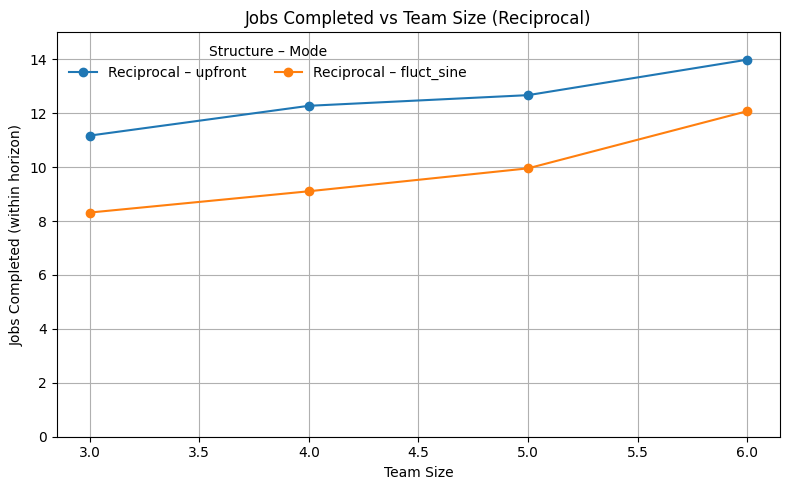

In [31]:
TEAM_SIZES = [3, 4, 5, 6]
REPS = 200
modes = ["upfront", "fluct_sine"]

N_JOBS = 14      
HORIZON = 300       
SERVICE_MEAN = 20.0
period = 50

records = []
raw_records = []  
for size in TEAM_SIZES:
    # lam_const = 0.046
    # lam_mean_sine = 0.0467
    # lam_const = 0.055
    lam_const = 0.05
    lam_mean_sine = 0.052
    # lam_mean_sine = 0.057
    amp_sine = 6

    for mode in modes:  
        comp_runs, flow_runs, thr_runs = [], [], []
        arrivals_counts = []
        for rep in range(REPS):
            seed = 100_000 * (hash(mode) % 1000) + size * 10_000 + rep

            if mode == "upfront":
                lam = 0.0
                a = 0.0
            elif mode == "constant":
                lam = lam_const
                a = 0.0
            elif mode == "fluct_sine":
                lam = lam_mean_sine
                a = amp_sine

            jobs_completed, throughput, mean_flow, logs = simulate_reciprocal(
                team_size=size,
                seed=seed,
                workload_mode=mode,
                N_JOBS=N_JOBS,
                lambda_rate=lam,
                amp=a,
                period=period,
                faults_per_worker=0
            )
            comp_runs.append(jobs_completed)
            thr_runs.append(throughput)
            flow_runs.append(mean_flow)

            arrivals_df = pd.DataFrame(logs["arrivals"], columns=["t","job"]).sort_values("t")
            enqueue_df  = pd.DataFrame(logs["enqueue"],  columns=["t","job","stage"]).sort_values(["t","stage"])
            start_df    = pd.DataFrame(logs["start"],    columns=["t","job","stage","worker"]).sort_values("t")
            finish_df   = pd.DataFrame(logs["finish"],   columns=["t","job","stage","worker"]).sort_values("t")

            # if mode == "fluct_sine":
                # print(arrivals_df.head(15))

            # arrivals_counts.append(len(logs["arrivals"]))
            arrivals_counts.append(sum(1 for t, _ in logs["arrivals"] if t < 280)) # jobs arriving that could feasibly be completed

            raw_records.append({
                "workload": mode,
                "team_size": size,
                "rep": rep,
                "jobs_completed": jobs_completed,
                "throughput": throughput,
                "mean_flow": mean_flow,
                "arrivals_before280": arrivals_counts[-1],
            })
            
            mean_jobs = float(np.mean(comp_runs))
            std_jobs  = float(np.std(comp_runs, ddof=1))       
            sem_jobs  = float(std_jobs / np.sqrt(REPS))        
            ci95_jobs = float(1.96 * sem_jobs)                   

        records.append({
            "Structure": "Reciprocal",
            "Team Size": size,
            "Workload Mode": mode,
            "Jobs Completed": float(np.mean(comp_runs)),
            "Throughput (jobs/tick)": float(np.mean(thr_runs)),
            "Jobs Completed": mean_jobs,
            "Jobs Completed SEM": sem_jobs,
            "Jobs Completed CI95": ci95_jobs,
            "Mean Flow Time (s)": float(np.nanmean(flow_runs)),
            "Avg Jobs Arrived": float(np.mean(arrivals_counts)),
            "Horizon": HORIZON,
            "N_JOBS_offered": N_JOBS
        })

        
df = pd.DataFrame(records)
# print(df)
print(df[["Workload Mode", "Avg Jobs Arrived"]])

plt.figure(figsize=(8, 5))
for struct in sorted(df["Structure"].unique()):
    for mode in modes:
        subset = (
            df[(df["Structure"] == struct) & (df["Workload Mode"] == mode)]
            .sort_values("Team Size")
        )
        if subset.empty:
            continue
        plt.plot(
            subset["Team Size"],
            subset["Jobs Completed"],
            marker="o",
            label=f"{struct} – {mode}"
        )

plt.xlabel("Team Size")
plt.ylabel("Jobs Completed (within horizon)")
plt.title("Jobs Completed vs Team Size (Reciprocal)")
plt.grid(True)
plt.legend(ncol=2, frameon=False, title="Structure – Mode")
plt.ylim(0,15)
plt.tight_layout()
plt.show()

In [32]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
df_raw = pd.DataFrame(raw_records)
df_raw["workload"] = df_raw["workload"].astype("category")
df_raw["team_size"] = df_raw["team_size"].astype("category")

model = smf.ols("jobs_completed ~ C(workload) * C(team_size)", data=df_raw).fit()
print(anova_lm(model, typ=2))

                             sum_sq      df           F         PR(>F)
C(workload)               2835.5625     1.0  555.959094  1.115816e-105
C(team_size)              2298.3225     3.0  150.208092   1.029271e-85
C(workload):C(team_size)    86.3625     3.0    5.644267   7.592367e-04
Residual                  8119.6900  1592.0         NaN            NaN


In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from numpy.linalg import norm
from collections import defaultdict

import hashlib

def stable_seed(*parts, mod=(2**31 - 1)):
    s = "|".join(map(str, parts)).encode()
    # 8 bytes → 64-bit int; then mod to fit RNGs that want < 2**31
    return int(hashlib.blake2b(s, digest_size=8).hexdigest(), 16) % mod

# Extract K deterministic schedules from simulations

def collect_pool_for_condition(mode, size, reps, horizon,
                               lam_const, lam_mean_sine, amp_sine, period,
                               N_JOBS, faults_per_worker=0, B=12):
    pool = []
    for rep in range(reps):
        # seed = 100_000 * (hash(mode) % 1000) + size * 10_000 + rep
        seed = stable_seed("collect_pool_for_mode", mode, rep)
        if mode == "upfront":
            lam, a = 0.0, 0.0
        elif mode == "constant":
            lam, a = lam_const, 0.0
        elif mode == "fluct_sine":
            lam, a = lam_mean_sine, amp_sine
        else:
            raise ValueError(f"Unknown mode {mode}")

        jobs_completed, throughput, mean_flow, logs = simulate_reciprocal(
            team_size=size, seed=seed, workload_mode=mode,
            N_JOBS=N_JOBS, lambda_rate=lam, amp=a, period=period,
            faults_per_worker=faults_per_worker, log_events=True
        )

        arrivals_before280 = sum(1 for t,_ in logs["arrivals"] if t < 280)
        arr_times = extract_arrival_schedule(logs)
        feat = features_from_run(jobs_completed, mean_flow, throughput,
                                 arrivals_before280, arr_times, horizon, B=B)

        pool.append({
            "condition": (mode, size),
            "seed": seed,
            "arrival_schedule": arr_times,
            "feat": feat,
            "metrics": {
                "jobs_completed": float(jobs_completed),
                "mean_flow": float(mean_flow) if not np.isnan(mean_flow) else 0.0,
                "throughput": float(throughput),
                "arrivals_before280": float(arrivals_before280)
            }
        })
    return pool

def pick_kmeans_medoids(candidates, k=25, random_state=42):
    if len(candidates) == 0:
        return []
    X = np.vstack([c["feat"] for c in candidates])
    # Standardize for fair clustering across metrics
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    k = min(k, len(candidates))  # guard when pool is small
    km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
    labels = km.fit_predict(Xs)
    centers = km.cluster_centers_

    chosen = []
    for cidx in range(k):
        idxs = np.where(labels == cidx)[0]
        if len(idxs) == 0:
            continue
        center = centers[cidx]
        # pick the point with min distance to center (medoid proxy)
        best_i = min(idxs, key=lambda i: norm(Xs[i] - center))
        chosen.append(candidates[best_i])
    return chosen


def pick_kmeans_random(candidates, k=25, random_state=42, sample_seed=123):
    """
    Cluster candidates (using standardized features) into k clusters,
    then pick ONE RANDOM candidate from each non-empty cluster.
    """
    if len(candidates) == 0:
        return []
    k = min(k, len(candidates))

    # Stack features and standardize
    X = np.vstack([c["feat"] for c in candidates])
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # K-means clustering
    km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
    labels = km.fit_predict(Xs)

    rng = random.Random(sample_seed)
    picks = []
    for cidx in range(k):
        idxs = np.where(labels == cidx)[0]
        if len(idxs) == 0:
            continue
        # choose a random member of this cluster
        i = rng.choice(list(idxs))
        picks.append(candidates[i])

    return picks

In [34]:
import os, json

def build_and_save_schedules(modes, team_sizes, reps_per_condition,
                             horizon, lam_const, lam_mean_sine, amp_sine, period,
                             N_JOBS, faults_per_worker=0, k=25, B=12,
                             outdir="schedules_kmeans"):
    os.makedirs(outdir, exist_ok=True)
    summary = []

    for mode in modes:
        for size in team_sizes:
            pool = collect_pool_for_condition(
                mode, size, reps=reps_per_condition, horizon=horizon,
                lam_const=lam_const, lam_mean_sine=lam_mean_sine, amp_sine=amp_sine,
                period=period, N_JOBS=N_JOBS, faults_per_worker=faults_per_worker, B=B
            )
            picks = pick_kmeans_medoids(pool, k=k, random_state=42)
            # picks = pick_kmeans_random(pool, k=k, random_state=42)

            out = {
                "mode": mode,
                "team_size": size,
                "k": k,
                "schedules": [
                    {"seed": p["seed"],
                     "arrival_schedule": p["arrival_schedule"],
                     "metrics": p["metrics"]}
                    for p in picks
                ]
            }
            with open(os.path.join(outdir, f"{mode}_size{size}.json"), "w") as f:
                json.dump(out, f, indent=2)

            # quick summary stats of chosen subset
            if picks:
                jc = np.array([p["metrics"]["jobs_completed"] for p in picks], float)
                mf = np.array([p["metrics"]["mean_flow"] for p in picks], float)
                summary.append({
                    "mode": mode, "team_size": size,
                    "n_pool": len(pool), "k_kept": len(picks),
                    "jobs_completed_mean_subset": float(jc.mean()),
                    "mean_flow_subset": float(mf.mean())
                })

    return summary

In [35]:
# RANDOM SAMPLING (WITHOUT DUPLICATES) FOR EACH WORKLOAD CONDITION 

import hashlib

def stable_seed(*parts, mod=(2**31 - 1)):
    s = "|".join(map(str, parts)).encode()
    # 8 bytes → 64-bit int; then mod to fit RNGs that want < 2**31
    return int(hashlib.blake2b(s, digest_size=8).hexdigest(), 16) % mod

def collect_pool_for_mode(mode, reps, horizon,
                          lam_const, lam_mean_sine, amp_sine, period,
                          N_JOBS, faults_per_worker=0, gen_team_size=3):
    """Generate candidate schedules for a MODE. Seed does NOT depend on team size."""
    pool = []
    for rep in range(reps):
        # seed = 100_000 * (hash(mode) % 1000) + rep
        seed = stable_seed("collect_pool_for_mode", mode, rep)
        if mode == "upfront":
            lam, a = 0.0, 0.0
        elif mode == "constant":
            lam, a = lam_const, 0.0
        elif mode == "fluct_sine":
            lam, a = lam_mean_sine, amp_sine
        else:
            raise ValueError(f"Unknown mode {mode}")

        jobs_completed, throughput, mean_flow, logs = simulate_reciprocal(
            team_size=gen_team_size,
            seed=seed,
            workload_mode=mode,
            N_JOBS=N_JOBS,
            lambda_rate=lam, amp=a, period=period,
            faults_per_worker=faults_per_worker,
            log_events=True
        )
        arr_times = extract_arrival_schedule(logs)  # list of arrival times
        pool.append({
            "mode": mode,
            "seed": seed,
            "arrival_schedule": arr_times,
            "diag": {
                "jobs_completed": float(jobs_completed),
                "mean_flow": float(mean_flow) if not np.isnan(mean_flow) else 0.0,
                "throughput": float(throughput),
            }
        })
    return pool

def _dedupe_by_arrivals(pool):
    """Collapse candidates with identical arrival schedules."""
    key2item = {}
    for c in pool:
        # Use a tuple for hashable equality; you can round times if needed.
        k = tuple(c["arrival_schedule"])
        if k not in key2item:
            key2item[k] = c
    return list(key2item.values())

def build_and_save_schedules_by_mode_random(
    modes, reps_per_mode, horizon,
    lam_const, lam_mean_sine, amp_sine, period, N_JOBS,
    faults_per_worker=0, k=25, outdir="schedules_random",
    rng_seed=123, dedupe=True, gen_team_size=3
):
    os.makedirs(outdir, exist_ok=True)
    rng = random.Random(rng_seed)
    summary = []

    for mode in modes:
        pool = collect_pool_for_mode(
            mode=mode, reps=reps_per_mode, horizon=horizon,
            lam_const=lam_const, lam_mean_sine=lam_mean_sine, amp_sine=amp_sine, period=period,
            N_JOBS=N_JOBS, faults_per_worker=faults_per_worker, gen_team_size=gen_team_size
        )
        if dedupe:
            pool = _dedupe_by_arrivals(pool)

        if len(pool) == 0:
            picks = []
        else:
            kk = min(k, len(pool))
            picks = rng.sample(pool, kk)

        out = {
            "mode": mode,
            "k": int(k),
            "sampled": int(len(picks)),
            "sampling": "uniform_random_no_replacement",
            "schedules": [
                {"seed": p["seed"], "arrival_schedule": p["arrival_schedule"], "diag": p.get("diag", {})}
                for p in picks
            ],
        }
        with open(os.path.join(outdir, f"{mode}.json"), "w") as f:
            json.dump(out, f, indent=2)

        # tiny summary
        totals = [len([t for t in s["arrival_schedule"] if 0 <= t < horizon]) for s in out["schedules"]]
        summary.append({
            "mode": mode,
            "n_pool": len(pool),
            "k_requested": int(k),
            "k_sampled": len(picks),
            "arrivals_mean": float(np.mean(totals)) if totals else 0.0,
            "arrivals_std": float(np.std(totals, ddof=1)) if len(totals) > 1 else 0.0,
        })

    return summary

def load_bank_by_mode(schedule_dir):
    bank = {}
    for fn in os.listdir(schedule_dir):
        if not fn.endswith(".json"):
            continue
        with open(os.path.join(schedule_dir, fn)) as f:
            pack = json.load(f)
        bank[pack["mode"]] = pack["schedules"]
    return bank

def eval_condition(mode, size, schedules, *, service_seed_base=777, horizon=1000,
                   N_JOBS=999999, period=None, faults_per_worker=0):
    rows = []
    for i, s in enumerate(schedules):
        schedule = s["arrival_schedule"]
        arrivals_total = sum(1 for t in schedule if 0 <= t < horizon)
        arrivals_before280 = sum(1 for t in schedule if 0 <= t < 280)

        seed = service_seed_base + i
        jobs_completed, throughput, mean_flow, _ = simulate_reciprocal(
            team_size=size,
            seed=seed,
            workload_mode=mode,
            arrival_schedule=schedule,
            N_JOBS=N_JOBS,
            lambda_rate=0.0, amp=0.0, period=period,
            faults_per_worker=faults_per_worker,
            log_events=False
        )
        rows.append({
            "jobs_completed": float(jobs_completed),
            "throughput": float(throughput),
            "mean_flow": float(mean_flow) if not np.isnan(mean_flow) else np.nan,
            "arrivals_total": float(arrivals_total),
            "arrivals_before280": float(arrivals_before280),
        })
    return rows

def sem(x):
    x = np.asarray(x, float)
    n = len(x)
    return x.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0

def ci95(x): return 1.96 * sem(np.asarray(x, float))

def analyze_and_plot(modes, team_sizes, bank, horizon, period, N_JOBS):
    records = []
    for mode in modes:
        schedules = bank.get(mode, [])
        for size in team_sizes:
            if not schedules: continue
            rows = eval_condition(mode, size, schedules,
                                  service_seed_base=777, horizon=horizon,
                                  N_JOBS=N_JOBS, period=period)
            jc  = np.array([r["jobs_completed"] for r in rows], float)
            mf  = np.array([r["mean_flow"] for r in rows], float)
            thr = np.array([r["throughput"] for r in rows], float)
            arr = np.array([r["arrivals_total"] for r in rows], float)
            arr280 = np.array([r["arrivals_before280"] for r in rows], float)
            records.append({
                "Structure": "Reciprocal",
                "Team Size": size,
                "Workload Mode": mode,
                "n_schedules": len(rows),
                "Jobs Completed": float(jc.mean()),
                "Jobs Completed SEM": sem(jc),
                "Jobs Completed CI95": ci95(jc),
                "Throughput (jobs/tick)": float(thr.mean()),
                "Mean Flow Time (s)": float(np.nanmean(mf)),
                "Mean Flow Time CI95": ci95(mf[~np.isnan(mf)] if np.isnan(mf).any() else mf),
                "Arrivals (total) Mean": float(arr.mean()),
                "Arrivals (total) CI95": ci95(arr),
                "Arrivals (<280) Mean": float(arr280.mean()),
                "Arrivals (<280) CI95": ci95(arr280),
                "Max Jobs": float(arr.max()) if len(arr) else 0.0,
            })

    df = pd.DataFrame(records).sort_values(["Structure","Workload Mode","Team Size"])
    print(df[["Workload Mode","Team Size","Arrivals (total) Mean","Arrivals (<280) Mean","n_schedules"]])

    plt.figure(figsize=(8,5))
    for mode in modes:
        subset = df[(df["Structure"]=="Reciprocal") & (df["Workload Mode"]==mode)].sort_values("Team Size")
        if subset.empty: continue
        plt.errorbar(
            subset["Team Size"], subset["Jobs Completed"],
            yerr=subset["Jobs Completed SEM"], marker="o", capsize=3, elinewidth=1,
            label=f"{mode}"
        )
    plt.xlabel("Team Size")
    plt.ylabel("Jobs Completed (within horizon)")
    plt.title("Jobs Completed vs Team Size (Randomly sampled schedules)")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, frameon=False, title="Mode")
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()
    return df

In [36]:
def make_upfront_schedules(k: int, N_JOBS: int):
    # Each "schedule" is just a dict with an arrival_schedule; team size doesn't matter for arrivals
    zero_schedule = [0] * N_JOBS
    return [{"arrival_schedule": zero_schedule, "seed": i} for i in range(k)]

  Workload Mode  Team Size  Arrivals (total) Mean  Arrivals (<280) Mean  \
4    fluct_sine          3                   14.5                  13.4   
5    fluct_sine          4                   14.5                  13.4   
6    fluct_sine          5                   14.5                  13.4   
7    fluct_sine          6                   14.5                  13.4   
0       upfront          3                   14.0                  14.0   
1       upfront          4                   14.0                  14.0   
2       upfront          5                   14.0                  14.0   
3       upfront          6                   14.0                  14.0   

   n_schedules  
4           10  
5           10  
6           10  
7           10  
0           10  
1           10  
2           10  
3           10  


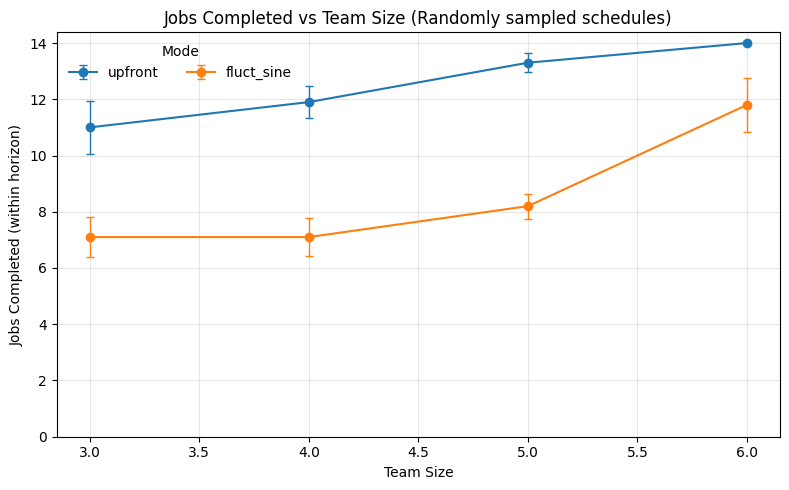

n, df_resid: 80 72.0
                          sum_sq    df          F        PR(>F)
C(workload)                320.0   1.0  75.789474  7.382022e-13
C(team_size)               178.3   3.0  14.076316  2.586543e-07
C(workload):C(team_size)    25.5   3.0   2.013158  1.196971e-01
Residual                   304.0  72.0        NaN           NaN
                    Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      jobs_completed
No. Observations:        80           Method:                  REML          
No. Groups:              10           Scale:                   3.1381        
Min. group size:         8            Log-Likelihood:          -158.5085     
Max. group size:         8            Converged:               Yes           
Mean group size:         8.0                                                 
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z 

In [37]:
SCHEDULE_DIR = "schedules_random_arrivals"
modes = ["upfront", "fluct_sine"]
team_sizes = [3,4,5,6]

# RANDOM SAMPLING FOR PILOT

# summary = build_and_save_schedules_by_mode_random(
#     modes=modes,
#     reps_per_mode=200,
#     horizon=HORIZON,
#     lam_const=lam_const, lam_mean_sine=lam_mean_sine, amp_sine=amp_sine, period=period,
#     N_JOBS=N_JOBS,
#     faults_per_worker=0,
#     k=3,                 # how many to sample per workload condition (based on previous study sample size)
#     outdir=SCHEDULE_DIR,
#     rng_seed=11,         # reproducible seed
#     dedupe=True,          # turn off if you want exact raw sampling
#     gen_team_size=3
# )
# print("Build summary:", summary)

# bank = load_bank_by_mode(SCHEDULE_DIR)

bank_saved = load_bank_by_mode(SCHEDULE_DIR)   

K = 10 # number of teams per condition
bank = {
    "upfront": make_upfront_schedules(K, N_JOBS),
    "fluct_sine": bank_saved.get("fluct_sine", [])[:K],  
}

_df = analyze_and_plot(
    modes=modes,
    team_sizes=team_sizes,
    bank=bank,
    horizon=HORIZON,
    period=period,
    N_JOBS=N_JOBS
)

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

raw_records = []
service_seed_base = 777  # different rng for service times per schedule index

for mode in ["upfront", "fluct_sine"]:
    schedules = bank.get(mode, [])
    for size in [3,4,5,6]:
        rows = eval_condition(
            mode, size, schedules,
            service_seed_base=service_seed_base,
            horizon=HORIZON
        )
        for i, r in enumerate(rows):
            raw_records.append({
                "workload": mode,
                "team_size": size,
                "schedule_idx": i,
                "jobs_completed": r["jobs_completed"],
                "throughput": r["throughput"],
                "mean_flow": r["mean_flow"],
            })

import numpy as np, pandas as pd
raw = pd.DataFrame(raw_records)

# 3) Clean and cast
raw = raw[np.isfinite(raw["jobs_completed"])]
raw = raw[raw[["workload","team_size"]].notna().all(axis=1)].copy()
raw["workload"] = raw["workload"].astype("category")
raw["team_size"] = raw["team_size"].astype("category")

# 4) Fit OLS with interaction; now residual df = (cells*K) - params = 8*10 - 8 = 72
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

model = smf.ols("jobs_completed ~ C(workload) * C(team_size)", data=raw).fit()
print("n, df_resid:", raw.shape[0], model.df_resid)  # sanity check (>0)
print(anova_lm(model, typ=2))

import statsmodels.api as sm
md = sm.MixedLM.from_formula(
    "jobs_completed ~ workload * team_size",
    groups="schedule_idx",
    data=raw
).fit()
print(md.summary())

In [38]:
def simulate_pooled(team_size,
                    seed,
                    workload_mode="upfront",
                    N_JOBS=14,
                    lambda_rate=14/250,
                    amp=0.8,
                    period=150,
                    faults_per_worker=0,
                    log_events=True,
                    arrival_schedule=None):
    """
    Pooled structure: any free worker can pull the next available (job, stage) token
    from a single shared ready queue. Stage order per job is enforced: stage s+1 is
    enqueued only after stage s completes.
    """
    # --- logs ---
    arrivals_log, enqueue_log, start_log, finish_log = [], [], [], []

    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)

    # Single shared ready queue across stages
    ready = deque()

    # Per-job bookkeeping
    arrival_time = {}         # j -> t_arrival (when stage 0 was created)
    completion_time = {}      # j -> t_completion (after last stage completed)
    token_done = set()        # {(j,s)} completed

    # Workers (pooled: no fixed stage)
    workers = []
    for _ in range(team_size):
        intervals = []
        for _ in range(faults_per_worker):
            start = rng.uniform(0, HORIZON - FAULT_DUR)
            intervals.append((start, start + FAULT_DUR))
        workers.append({"remain": 0, "token": None, "faults": intervals})

    next_job_id = 0  # how many jobs have arrived (or been created via schedule/stochastic)

    # Upfront: create all jobs at t=0 by enqueuing their first stage
    if arrival_schedule is None and workload_mode == "upfront":
        for j in range(N_JOBS):
            # enqueue only stage 0; later stages will be released upon completion
            ready.append((j, 0))
            if log_events: enqueue_log.append((0, j, 0))
            arrival_time[j] = 0
            if log_events: arrivals_log.append((0, j))
        next_job_id = N_JOBS

    # --- main time loop ---
    for t in range(HORIZON):

        # 1) Arrivals (explicit schedule)
        if arrival_schedule is not None:
            # enqueue all new jobs that arrive exactly at time t
            count_here = sum(1 for tt in arrival_schedule if tt == t)
            for _ in range(count_here):
                j = next_job_id
                ready.append((j, 0))
                if log_events: enqueue_log.append((t, j, 0))
                arrival_time[j] = t
                if log_events: arrivals_log.append((t, j))
                next_job_id += 1

        # 1b) Arrivals (stochastic for non-upfront modes)
        elif workload_mode in ("constant", "fluct_sine", "fluct_square", "fluct_square_nb"):
            lam = lam_t(t, workload_mode, lambda_rate, amp, period)
            n_new = int(np_rng.poisson(lam=max(lam, 0.0)))
            for _ in range(n_new):
                j = next_job_id
                ready.append((j, 0))
                if log_events: enqueue_log.append((t, j, 0))
                arrival_time[j] = t
                if log_events: arrivals_log.append((t, j))
                next_job_id += 1

        # 2) Worker updates (finish then (maybe) start)
        for wid, w in enumerate(workers):
            # progress current service
            if w["remain"] > 0:
                w["remain"] -= 1
                if w["remain"] == 0:
                    j, s = w["token"]
                    w["token"] = None
                    token_done.add((j, s))
                    if log_events: finish_log.append((t, j, s, wid))

                    # release next stage for this job, or mark completion
                    if s + 1 < STAGES:
                        ready.append((j, s + 1))
                        if log_events: enqueue_log.append((t, j, s + 1))
                    else:
                        completion_time[j] = t  # all stages done

            # start new work if possible
            in_fault = any(a <= t < b for a, b in w["faults"])
            if w["remain"] == 0 and not in_fault and ready:
                tok = ready.popleft()
                j, s = tok
                w["token"] = tok
                # service time (same as reciprocal)
                w["remain"] = max(1, math.ceil(rng.expovariate(1.0 / SERVICE_MEAN)))
                if log_events: start_log.append((t, j, s, wid))

    # --- stats ---
    total_arrived = next_job_id
    finished_ids = [j for j in range(total_arrived) if j in completion_time]
    jobs_completed = len(finished_ids)
    throughput = jobs_completed / max(1, HORIZON)

    flows = [completion_time[j] - arrival_time[j] for j in finished_ids]
    mean_flow_time = float(np.mean(flows)) if flows else float("nan")

    logs = None
    if log_events:
        logs = {
            "arrivals": arrivals_log,
            "enqueue":  enqueue_log,
            "start":    start_log,
            "finish":   finish_log,
        }

    return jobs_completed, throughput, mean_flow_time, logs

  Workload Mode  Team Size  Arrivals (total) Mean  Arrivals (<280) Mean  \
4    fluct_sine          3                   14.5                  13.4   
5    fluct_sine          4                   14.5                  13.4   
6    fluct_sine          5                   14.5                  13.4   
7    fluct_sine          6                   14.5                  13.4   
0       upfront          3                   14.0                  14.0   
1       upfront          4                   14.0                  14.0   
2       upfront          5                   14.0                  14.0   
3       upfront          6                   14.0                  14.0   

   n_schedules  
4           10  
5           10  
6           10  
7           10  
0            1  
1            1  
2            1  
3            1  


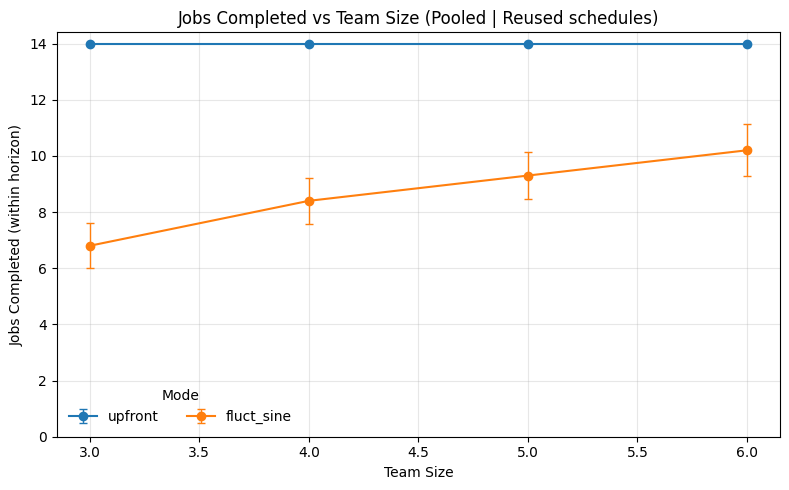

In [39]:
import re

def load_bank_by_mode_size(schedule_dir):
    """
    Returns: dict[(mode, gen_size)] -> list of schedule dicts
    where gen_size is parsed from filenames like 'fluct_sine_size3.json'.
    """
    bank = defaultdict(list)
    pat = re.compile(r'(?P<mode>[A-Za-z0-9_]+)_size(?P<size>\d+)\.json$')
    for fn in os.listdir(schedule_dir):
        if not fn.endswith(".json"):
            continue
        m = pat.match(fn)
        mode_from_name, size_from_name = (None, None)
        if m:
            mode_from_name = m.group("mode")
            size_from_name = int(m.group("size"))

        with open(os.path.join(schedule_dir, fn), "r") as f:
            pack = json.load(f)

        mode = mode_from_name or pack.get("mode") 
        gen_size = size_from_name                  

        key = (mode, gen_size)
        bank[key].extend(pack.get("schedules", []))
    return dict(bank)
    
SCHEDULE_DIR = "schedules_random_arrivals"   
modes = ["upfront", "fluct_sine"]           
team_sizes = [3,4,5,6]

bank_by_mode_size = load_bank_by_mode_size(SCHEDULE_DIR)

def eval_condition_with(simulate_fn, structure_label, mode, size, schedules, *,
                        service_seed_base=777, horizon=1000, N_JOBS=999999, period=None,
                        faults_per_worker=0):
    rows = []
    for i, s in enumerate(schedules):
        schedule = s["arrival_schedule"]
        arrivals_total = sum(1 for t in schedule if 0 <= t < horizon)
        arrivals_before280 = sum(1 for t in schedule if 0 <= t < 280)
        seed = service_seed_base + i

        jobs_completed, throughput, mean_flow, _ = simulate_fn(
            team_size=size,
            seed=seed,
            workload_mode=mode,          # still pass the mode for bookkeeping
            arrival_schedule=schedule,   # <-- key: reuse saved schedule
            N_JOBS=N_JOBS,
            lambda_rate=0.0, amp=0.0, period=period,   # arrivals come from schedule, so set rates to 0
            faults_per_worker=faults_per_worker,
            log_events=False
        )
        rows.append({
            "Structure": structure_label,
            "Team Size": size,
            "Workload Mode": mode,
            "jobs_completed": float(jobs_completed),
            "throughput": float(throughput),
            "mean_flow": float(mean_flow) if not np.isnan(mean_flow) else np.nan,
            "arrivals_total": float(arrivals_total),
            "arrivals_before280": float(arrivals_before280),
        })
    return rows

simulate_fn = simulate_pooled
structure_label = "Pooled"

def analyze_and_plot_pooled(modes, team_sizes, bank, horizon, period, N_JOBS):
    records = []
    for mode in modes:
        for size in team_sizes:
            schedules = bank.get((mode, size), [])
            if not schedules:
                print(f"[warn] no schedules for {(mode, size)}")
                continue
            rows = eval_condition_with(
                simulate_pooled, "Pooled", mode, size, schedules,
                service_seed_base=777, horizon=HORIZON, N_JOBS=N_JOBS, period=period
            )

            jc  = np.array([r["jobs_completed"]      for r in rows], float)
            mf  = np.array([r["mean_flow"]           for r in rows], float)
            thr = np.array([r["throughput"]          for r in rows], float)
            arr = np.array([r["arrivals_total"]      for r in rows], float)
            arr280 = np.array([r["arrivals_before280"] for r in rows], float)

            records.append({
                "Structure": structure_label,
                "Team Size": size,
                "Workload Mode": mode,
                "n_schedules": len(rows),
                "Jobs Completed": float(jc.mean()),
                "Jobs Completed SEM": sem(jc),
                "Jobs Completed CI95": ci95(jc),
                "Throughput (jobs/tick)": float(thr.mean()),
                "Mean Flow Time (s)": float(np.nanmean(mf)),
                "Mean Flow Time CI95": ci95(mf[~np.isnan(mf)] if np.isnan(mf).any() else mf),
                "Arrivals (total) Mean": float(arr.mean()),
                "Arrivals (total) CI95": ci95(arr),
                "Arrivals (<280) Mean": float(arr280.mean()),
                "Arrivals (<280) CI95": ci95(arr280),
                "Max Jobs": float(arr.max()) if len(arr) else 0.0,
            })

    df = pd.DataFrame(records).sort_values(["Structure","Workload Mode","Team Size"])
    print(df[["Workload Mode","Team Size","Arrivals (total) Mean","Arrivals (<280) Mean","n_schedules"]])

    plt.figure(figsize=(8,5))
    for mode in modes:
        subset = df[(df["Structure"]==structure_label) & (df["Workload Mode"]==mode)].sort_values("Team Size")
        if subset.empty: continue
        plt.errorbar(
            subset["Team Size"], subset["Jobs Completed"],
            yerr=subset["Jobs Completed SEM"], marker="o", capsize=3, elinewidth=1,
            label=f"{mode}"
        )
    plt.xlabel("Team Size"); plt.ylabel("Jobs Completed (within horizon)")
    plt.title(f"Jobs Completed vs Team Size ({structure_label} | Reused schedules)")
    plt.grid(True, alpha=0.3); plt.legend(ncol=2, frameon=False, title="Mode")
    plt.tight_layout(); plt.ylim(bottom=0); plt.show()
    return df
    
_df_pooled = analyze_and_plot_pooled(
    modes=modes,
    team_sizes=team_sizes,
    bank=bank_by_mode_size,
    horizon=HORIZON,
    period=period,
    N_JOBS=N_JOBS
)

  Workload Mode  Team Size  Arrivals (total) Mean  Arrivals (<280) Mean  \
4    fluct_sine          3                   14.5                  13.4   
5    fluct_sine          4                   14.5                  13.4   
6    fluct_sine          5                   14.5                  13.4   
7    fluct_sine          6                   14.5                  13.4   
0       upfront          3                   14.0                  14.0   
1       upfront          4                   14.0                  14.0   
2       upfront          5                   14.0                  14.0   
3       upfront          6                   14.0                  14.0   

   n_schedules  
4           10  
5           10  
6           10  
7           10  
0            1  
1            1  
2            1  
3            1  


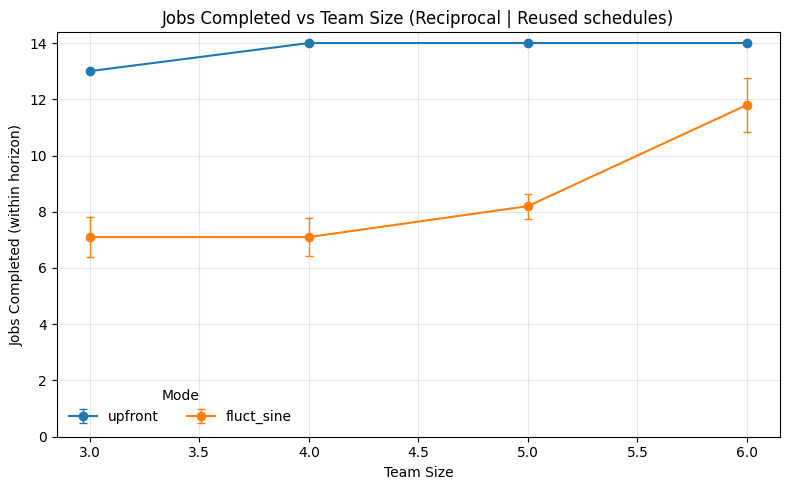

In [40]:
structure_label = "Reciprocal"
def analyze_and_plot_reciprocal(modes, team_sizes, bank, horizon, period, N_JOBS):
    records = []
    for mode in modes:
        for size in team_sizes:
            schedules = bank.get((mode, size), [])
            if not schedules:
                print(f"[warn] no schedules for {(mode, size)}")
                continue
            rows = eval_condition_with(
                simulate_reciprocal, "Reciprocal", mode, size, schedules,
                service_seed_base=777, horizon=HORIZON, N_JOBS=N_JOBS, period=period
            )

            jc  = np.array([r["jobs_completed"]      for r in rows], float)
            mf  = np.array([r["mean_flow"]           for r in rows], float)
            thr = np.array([r["throughput"]          for r in rows], float)
            arr = np.array([r["arrivals_total"]      for r in rows], float)
            arr280 = np.array([r["arrivals_before280"] for r in rows], float)

            records.append({
                "Structure": structure_label,
                "Team Size": size,
                "Workload Mode": mode,
                "n_schedules": len(rows),
                "Jobs Completed": float(jc.mean()),
                "Jobs Completed SEM": sem(jc),
                "Jobs Completed CI95": ci95(jc),
                "Throughput (jobs/tick)": float(thr.mean()),
                "Mean Flow Time (s)": float(np.nanmean(mf)),
                "Mean Flow Time CI95": ci95(mf[~np.isnan(mf)] if np.isnan(mf).any() else mf),
                "Arrivals (total) Mean": float(arr.mean()),
                "Arrivals (total) CI95": ci95(arr),
                "Arrivals (<280) Mean": float(arr280.mean()),
                "Arrivals (<280) CI95": ci95(arr280),
                "Max Jobs": float(arr.max()) if len(arr) else 0.0,
            })

    df = pd.DataFrame(records).sort_values(["Structure","Workload Mode","Team Size"])
    print(df[["Workload Mode","Team Size","Arrivals (total) Mean","Arrivals (<280) Mean","n_schedules"]])

    plt.figure(figsize=(8,5))
    for mode in modes:
        subset = df[(df["Structure"]==structure_label) & (df["Workload Mode"]==mode)].sort_values("Team Size")
        if subset.empty: continue
        plt.errorbar(
            subset["Team Size"], subset["Jobs Completed"],
            yerr=subset["Jobs Completed SEM"], marker="o", capsize=3, elinewidth=1,
            label=f"{mode}"
        )
    plt.xlabel("Team Size"); plt.ylabel("Jobs Completed (within horizon)")
    plt.title(f"Jobs Completed vs Team Size ({structure_label} | Reused schedules)")
    plt.grid(True, alpha=0.3); plt.legend(ncol=2, frameon=False, title="Mode")
    plt.tight_layout(); plt.ylim(bottom=0); plt.show()
    return df

_df_reciprocal = analyze_and_plot_reciprocal(
    modes=modes,
    team_sizes=team_sizes,
    bank=bank_by_mode_size,
    horizon=HORIZON,
    period=period,
    N_JOBS=N_JOBS
)